# Laboratorijska vježba 3 — pragovanje i binarna morfologija

In [1]:
from pathlib import Path
import math
import time
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

IMG = Path('images')

def show(images, titles, cmaps=None, figsize=(15, 5)):
    """Prikaži jednu ili više slika bez skrivene promjene raspona vrijednosti."""
    if not isinstance(images, (list, tuple)):
        images, titles = [images], [titles]
    if cmaps is None:
        cmaps = [None] * len(images)
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    axes = np.atleast_1d(axes)
    for ax, image, title, cmap in zip(axes, images, titles, cmaps):
        ax.imshow(image, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Zadatak 3 — jednostavno binarno pragovanje

Ista granica (`T = 150`) primjenjuje se funkcijom OpenCV-a i izrazom NumPy-a. Rezultati moraju biti jednaki.

Rezultati su jednaki: True


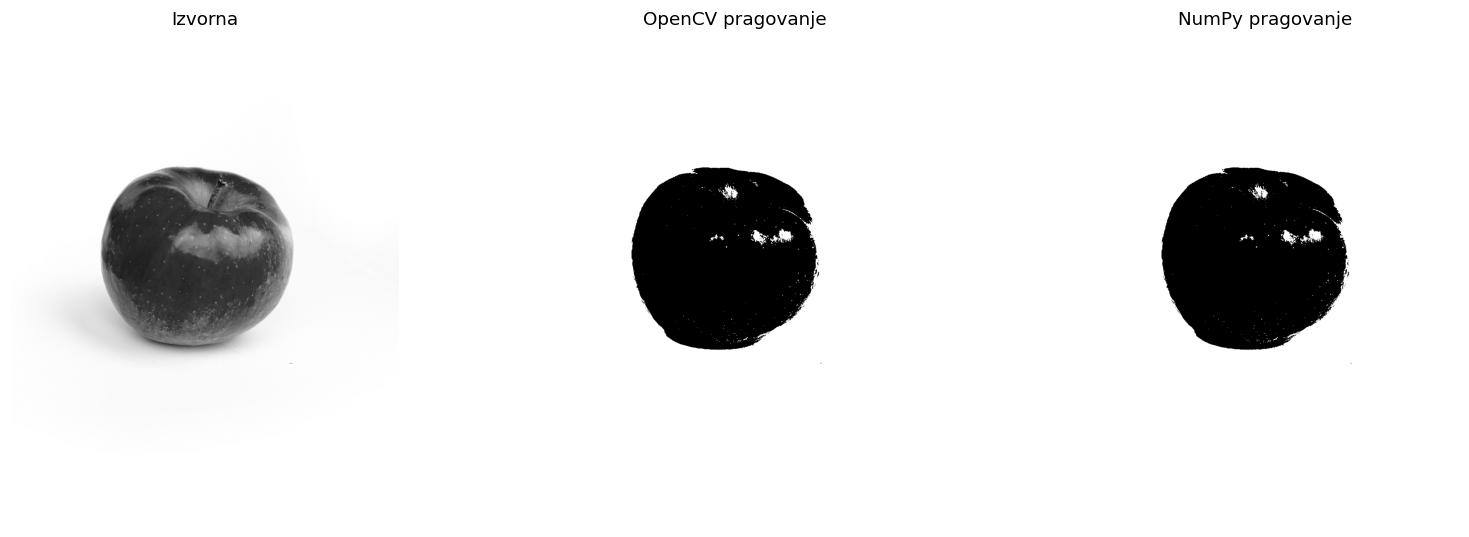

In [2]:
apple = cv.imread(str(IMG / 'apple.jpg'), cv.IMREAD_GRAYSCALE)
assert apple is not None, 'Slika apple.jpg nije pronađena.'
T = 150
_, threshold_cv = cv.threshold(apple, T, 255, cv.THRESH_BINARY)
threshold_np = np.where(apple > T, 255, 0).astype(np.uint8)
show([apple, threshold_cv, threshold_np],
     ['Izvorna', 'OpenCV pragovanje', 'NumPy pragovanje'], ['gray'] * 3)
print('Rezultati su jednaki:', np.array_equal(threshold_cv, threshold_np))

## Zadatak 4 — Otsuova binarizacija

Optimalni Otsuov prag: 165.0


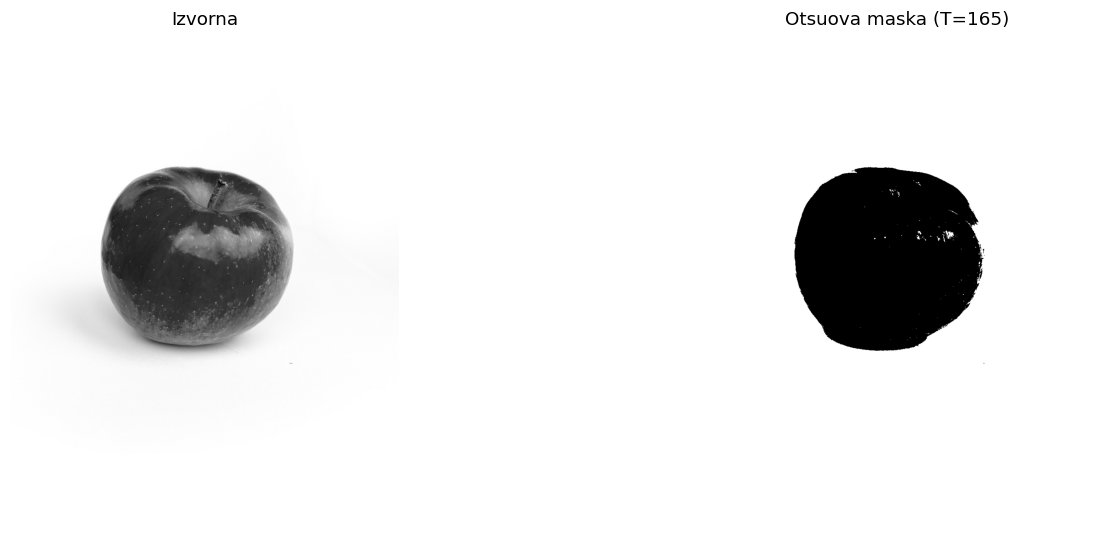

In [3]:
otsu_t, otsu_mask = cv.threshold(apple, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
show([apple, otsu_mask], ['Izvorna', f'Otsuova maska (T={otsu_t:.0f})'], ['gray', 'gray'])
print(f'Optimalni Otsuov prag: {otsu_t:.1f}')

## Zadatak 5 — maskiranje izvorne slike

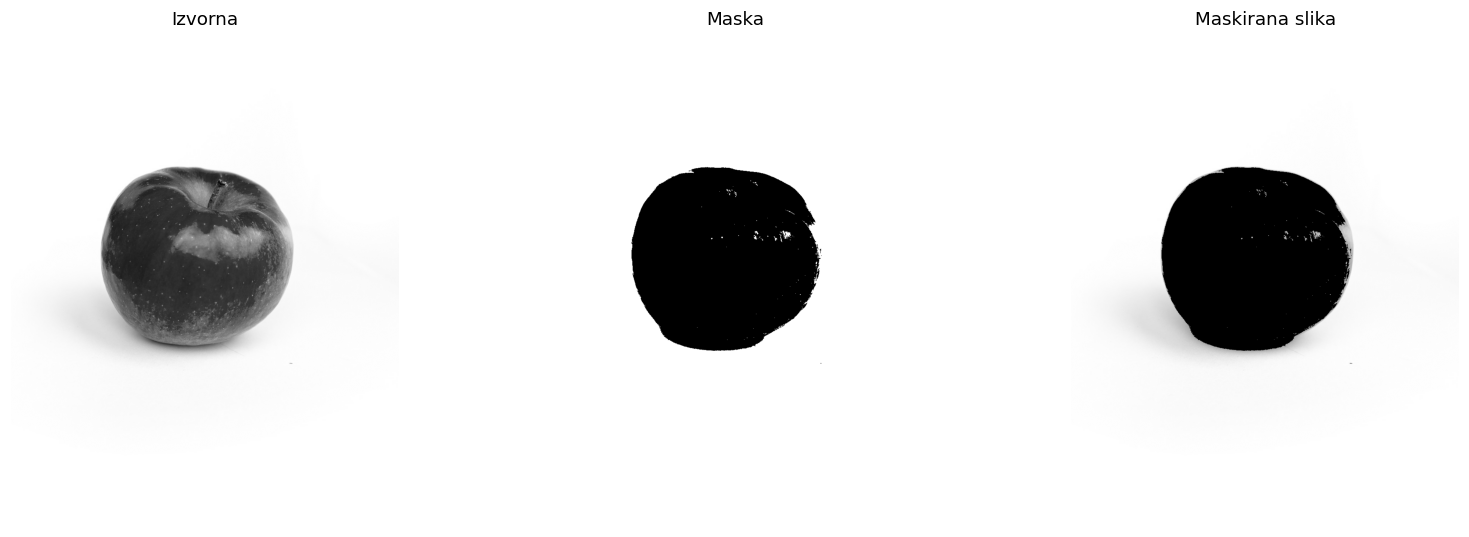

In [4]:
img_thresholded = cv.bitwise_and(apple, apple, mask=otsu_mask)
show([apple, otsu_mask, img_thresholded],
     ['Izvorna', 'Maska', 'Maskirana slika'], ['gray'] * 3)

## Morfološke operacije s različitim strukturnim elementima

Ispituju se pravokutni, eliptični i križni elementi veličine 3×3 i 5×5. Otvaranje uklanja sitne bijele strukture, zatvaranje popunjava male crne procjepe, a gradijent naglašava granice.

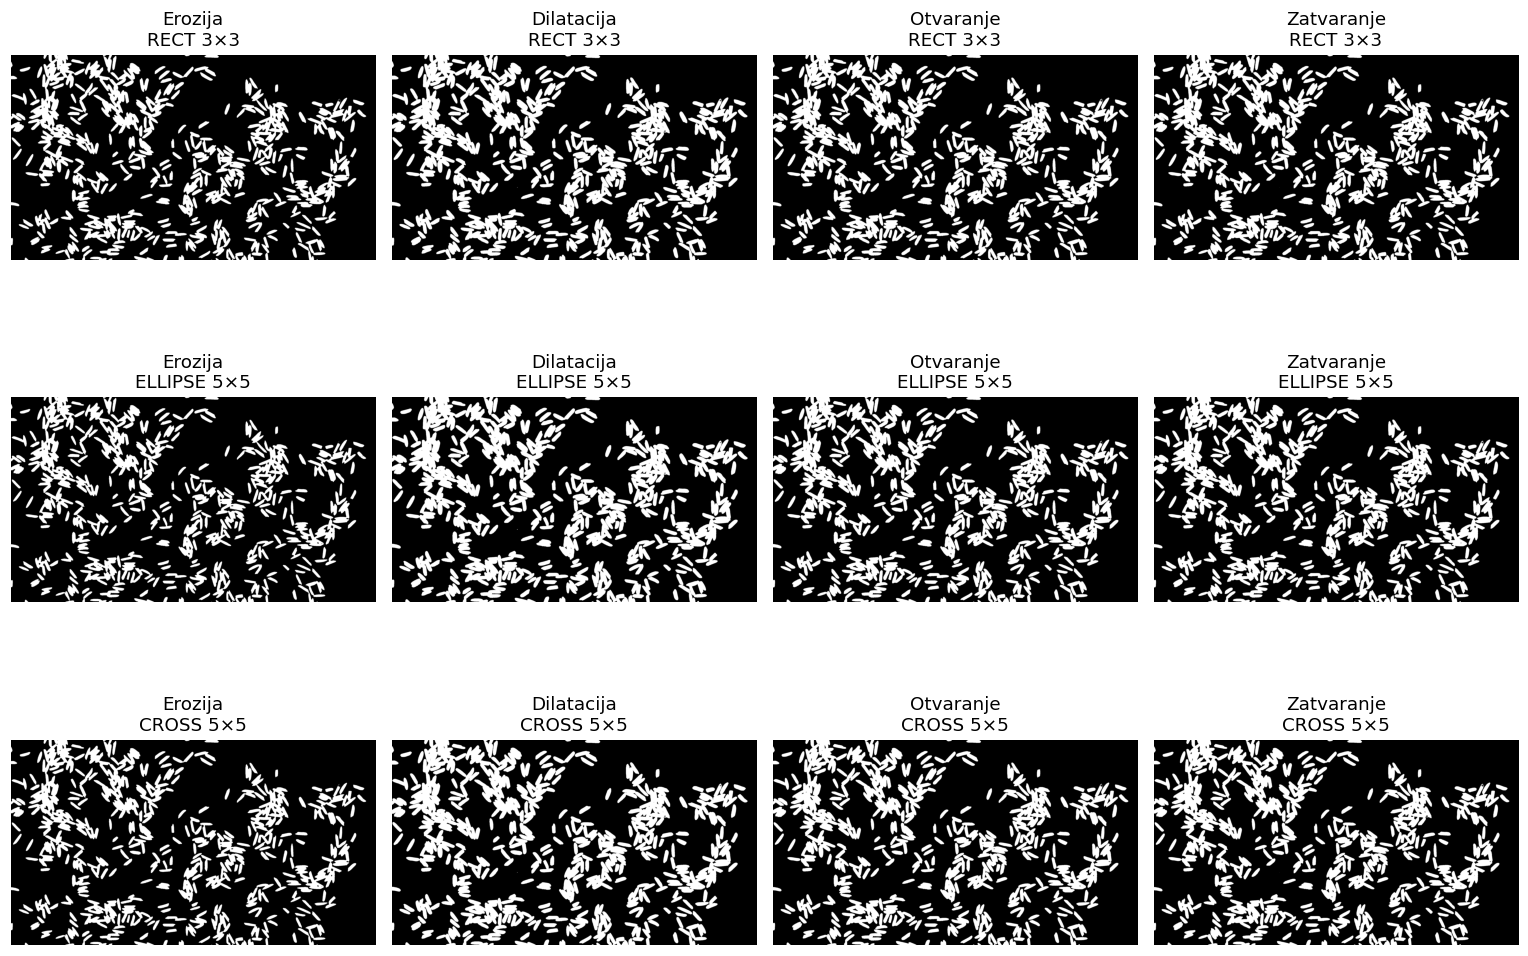

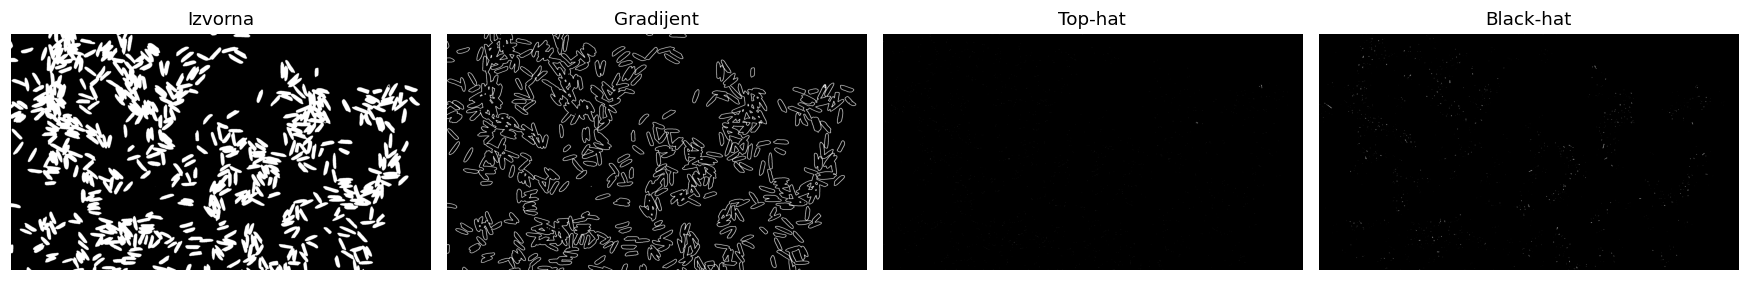

In [5]:
binary = cv.imread(str(IMG / 'binary_image.png'), cv.IMREAD_GRAYSCALE)
assert binary is not None

configs = [
    ('RECT 3×3', cv.MORPH_RECT, (3, 3)),
    ('ELLIPSE 5×5', cv.MORPH_ELLIPSE, (5, 5)),
    ('CROSS 5×5', cv.MORPH_CROSS, (5, 5)),
]

fig, axes = plt.subplots(len(configs), 4, figsize=(14, 10))
for row, (name, shape, size) in enumerate(configs):
    kernel = cv.getStructuringElement(shape, size)
    results = [
        cv.erode(binary, kernel),
        cv.dilate(binary, kernel),
        cv.morphologyEx(binary, cv.MORPH_OPEN, kernel),
        cv.morphologyEx(binary, cv.MORPH_CLOSE, kernel),
    ]
    for col, (result, operation) in enumerate(zip(results, ['Erozija', 'Dilatacija', 'Otvaranje', 'Zatvaranje'])):
        axes[row, col].imshow(result, cmap='gray')
        axes[row, col].set_title(f'{operation}\n{name}')
        axes[row, col].axis('off')
plt.tight_layout(); plt.show()

elliptic = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
gradient = cv.morphologyEx(binary, cv.MORPH_GRADIENT, elliptic)
tophat = cv.morphologyEx(binary, cv.MORPH_TOPHAT, elliptic)
blackhat = cv.morphologyEx(binary, cv.MORPH_BLACKHAT, elliptic)
show([binary, gradient, tophat, blackhat],
     ['Izvorna', 'Gradijent', 'Top-hat', 'Black-hat'], ['gray'] * 4, figsize=(16, 4))

## Zaključak

Veličina i oblik strukturnog elementa određuju koje se geometrijske strukture čuvaju. Križni element slabije djeluje na dijagonale, eliptični daje glađe konture, a veća jezgra uzrokuje izraženiju promjenu objekata.